# <font color="royalblue"><b> DETEKCIJA TEMA U *Youtube* KOMENTARIMA FANOVA EMISIE “GOING SEVENTEEN“ PRIMENOM BERTopic MODELA </b> </font>

## <font color="dodgerblue"><b> Imports </b> </font>

In [70]:
import spacy
import thinc

In [71]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.graph_objects as go

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

from gensim import corpora
from gensim.models import CoherenceModel, Word2Vec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

sns.set_theme(palette="pastel")

## <font color="dodgerblue"><b> Učitavanje i osnovna statistika </b> </font>

Podaci su prikupljeni sa YouTube kanala Going Seventeen putem YouTube Data API v3.
Skup podataka sadrži komentare iz dve kategorije:
- **recent** – komentari sa najnovijih videa i
- **popular** – komentari sa najgledanijih videa.

In [72]:
df = pd.read_csv('going_seventeen_comments.csv', encoding='utf-8-sig')
print(f'Ukupno redova: {len(df)}')
print(f'Kolone: {list(df.columns)}')
df.head()

Ukupno redova: 74552
Kolone: ['video_id', 'text', 'likes', 'date', 'video_title', 'type']


,video_id,text,likes,date,video_title,type
0,TJWUc875kpU,I think the production team could also create ...,0,2026-04-04T10:58:36Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent
1,TJWUc875kpU,"Honestly, i agree with Dino. I think they keep...",0,2026-04-04T06:20:04Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent
2,TJWUc875kpU,I’m glad Minghao brought up that he and Jun fe...,0,2026-04-04T00:35:36Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent
3,TJWUc875kpU,"I understand the discussion, but I think I wou...",0,2026-04-03T15:37:59Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent
4,TJWUc875kpU,Unpopular opinion: please bring the resolution...,2,2026-04-02T22:35:00Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent


In [73]:
print('=== OSNOVNA STATISTIKA ===')
print(f'Ukupno komentara:  {len(df):,}')
print(f'\nPo tipu videa:')
print(df['type'].value_counts().to_string())
print(f'\nPo videu:')
print(df['video_title'].value_counts().to_string())
print(f'\nLikes – prosek: {df["likes"].mean():.2f},  max: {df["likes"].max()}')

=== OSNOVNA STATISTIKA ===
Ukupno komentara:  74,552

Po tipu videa:
type
popular    64652
recent      9900

Po videu:
video_title
[GOING SEVENTEEN 2020] EP.27 술래잡기 #1 (The Tag #1)                                      11325
[GOING SEVENTEEN 2020] EP.44 TTT #1 (Hyperrealism Ver.)                                 8523
[GOING SEVENTEEN 2020] EP.25 디에잇과 12인의 그림자 #1 (THE 8 and the 12 Shadows #1)             7405
[GOING SEVENTEEN 2020] EP.45 TTT #2 (Hyperrealism Ver.)                                 6679
[GOING SEVENTEEN 2020] EP.23 드립 : 세븐틴 갓 탤런트 #1 (Ad-lib : Seventeen's got Talent #1)     6536
[GOING SEVENTEEN 2020] EP.40 돈't Lie Ⅱ #1 (Don't Lie Ⅱ #1)                              6126
[GOING SEVENTEEN] EP.32 순응특집 단짝 #2 (Best Friends #2)                                    5167
[GOING SEVENTEEN] EP.31 순응특집 단짝 #1 (Best Friends #1)                                    4676
[GOING SEVENTEEN] EP.18 TTT에 빠지다 #1 (Dive into TTT #1)                                  4516
[GOING SEVENTEEN] EP.24 부족오락관 #2

## <font color="dodgerblue"><b> Analiza teksta </b> </font>

Pre primene ikakvih NLP transformacija, analiziramo sirove komentare:
- **Dužinu komentara** 
- **Vokabular** 
- **Leksicku raznovrsnost (TTR)**

### <font color="steelblue"><b> Dužina komentara </b> </font>

=== STATISTIKA DUŽINE KOMENTARA ===
       char_count  word_count  sent_count
count    74552.00    74552.00    74552.00
mean       107.39       16.57        2.41
std        146.59       21.34        3.09
min          2.00        1.00        1.00
25%         46.00        7.00        1.00
50%         79.00       12.00        2.00
75%        123.00       18.00        3.00
max       8827.00      995.00      201.00


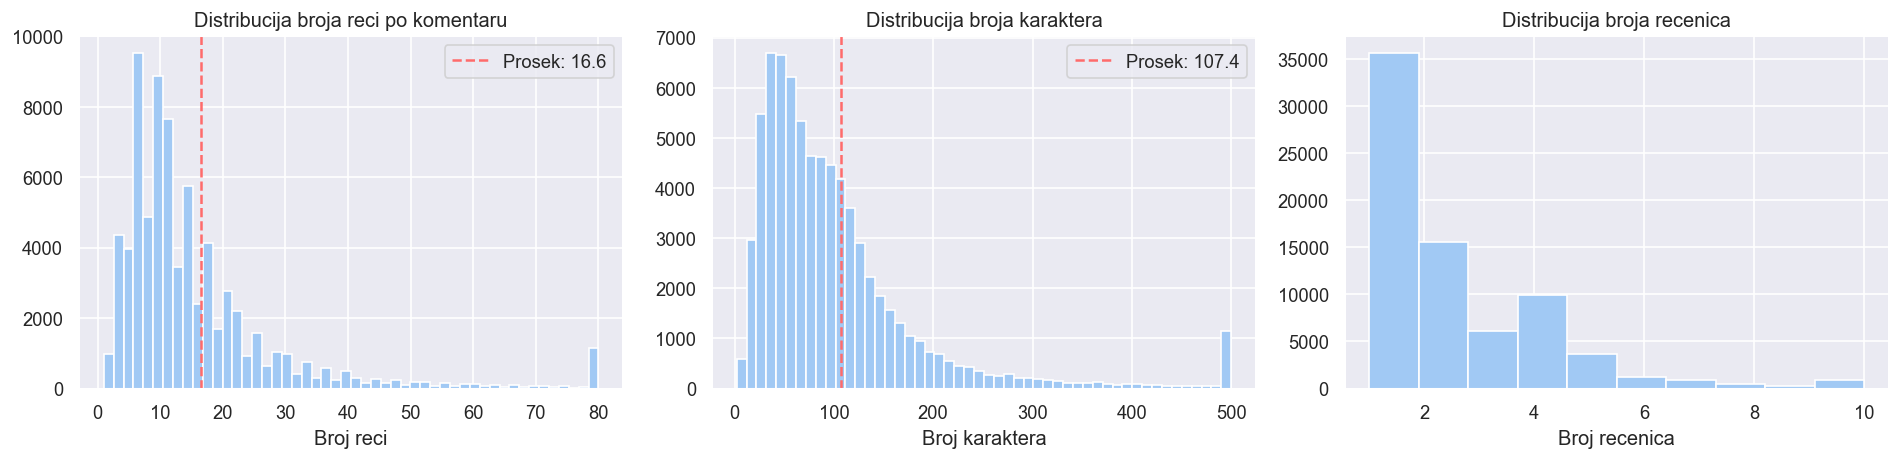

In [74]:
df['char_count'] = df['text'].apply(lambda x: len(str(x)))
df['word_count']  = df['text'].apply(lambda x: len(str(x).split()))
df['sent_count']  = df['text'].apply(
    lambda x: max(1, len(re.split(r'[.!?]+', str(x).strip()))))

desc = df[['char_count', 'word_count', 'sent_count']].describe().round(2)
print('=== STATISTIKA DUŽINE KOMENTARA ===')
print(desc)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['word_count'].clip(upper=80), bins=50, edgecolor='white')
axes[0].axvline(df['word_count'].mean(), color='#FF6B6B', linestyle='--',
                label=f'Prosek: {df["word_count"].mean():.1f}')
axes[0].set_title('Distribucija broja reci po komentaru')
axes[0].set_xlabel('Broj reci')
axes[0].legend()

axes[1].hist(df['char_count'].clip(upper=500), bins=50, edgecolor='white')
axes[1].axvline(df['char_count'].mean(), color='#FF6B6B', linestyle='--',
                label=f'Prosek: {df["char_count"].mean():.1f}')
axes[1].set_title('Distribucija broja karaktera')
axes[1].set_xlabel('Broj karaktera')
axes[1].legend()

axes[2].hist(df['sent_count'].clip(upper=10), bins=10, edgecolor='white')
axes[2].set_title('Distribucija broja recenica')
axes[2].set_xlabel('Broj recenica')

plt.tight_layout()
plt.show()

Statistika pokazuje da su komentari uglavnom **kratki i spontani** - prosečno oko 16 reči i 107 karaktera, sa 2-3 rečenice. Većina komentara sadrži 5-20 reči, dok su veoma dugi komentari retki. Ova varijabilnost ukazuje na to da fanovi kombinuje brze emotivne reakcije (kratki komentari, slang, emoji-ji) sa manjim brojem detaljnih analiza epizoda. Takva struktura potvrđuje da je detekcija tema izazovna i da su modeli zasnovani na semantičkim reprezentacijama (BERTopic) pogodniji od klasičnih pristupa.

### <font color="steelblue"><b> Vokabular i leksicka raznovrsnost (TTR) </b> </font>

In [75]:
df['ttr'] = df['text'].apply(
    lambda x: len(set(re.findall(r'[a-z]+', str(x).lower()))) /
              max(len(re.findall(r'[a-z]+', str(x).lower())), 1)
)

#HTML_ARTIFACTS = {'href', 'bra', 'amp', 'quot', 'br', 'lt', 'gt', 'http', 'https', 'www', 'com'}
all_words_raw = []
for tekst in df['text']:
    words = re.findall(r'[a-z]+', str(tekst).lower())
    #words = [w for w in words if w not in HTML_ARTIFACTS]
    all_words_raw.extend(words)

total_tokens  = len(all_words_raw)
unique_tokens = len(set(all_words_raw))
ttr_global    = unique_tokens / total_tokens

print('=== VOKABULAR ===')
print(f'Ukupno tokena:      {total_tokens:,}')
print(f'Jedinstvenih reči:  {unique_tokens:,}')
print(f'Globalni TTR:       {ttr_global:.4f}')

=== VOKABULAR ===
Ukupno tokena:      1,473,934
Jedinstvenih reči:  26,692
Globalni TTR:       0.0181


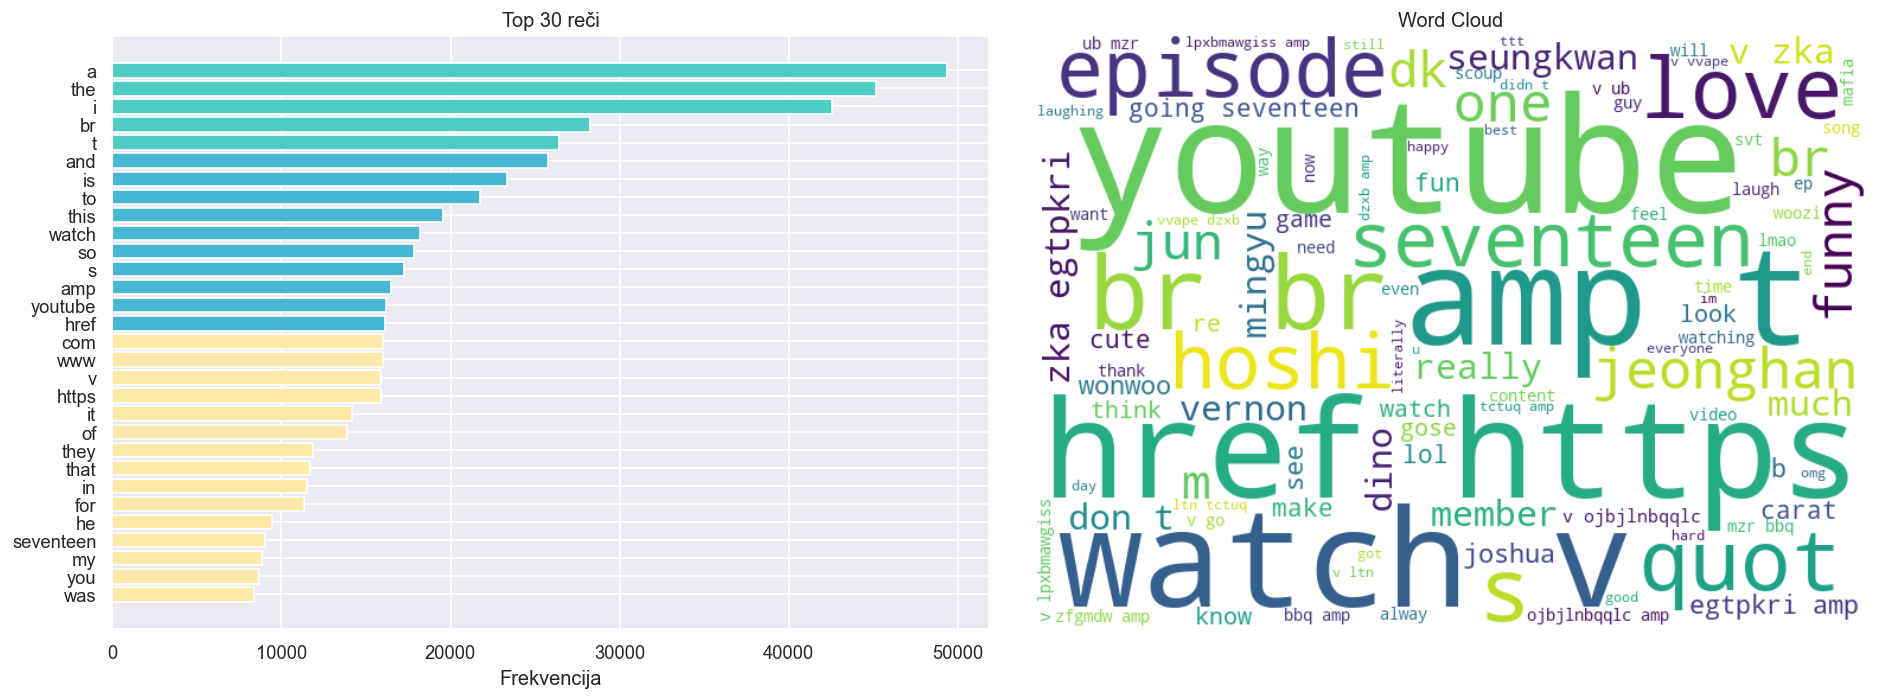

In [76]:
# filtered_words = [w for w in all_words_raw if w not in STOP_WORDS and len(w) > 2]
word_freq = Counter(all_words_raw)
top30 = word_freq.most_common(30)
words_top, counts_top = zip(*top30)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_bar = ['#4ECDC4' if i < 5 else '#45B7D1' if i < 15 else '#FFEAA7'
              for i in range(len(words_top))]
axes[0].barh(list(reversed(words_top)), list(reversed(counts_top)),
             color=list(reversed(colors_bar)), edgecolor='white')
axes[0].set_title('Top 30 reči')
axes[0].set_xlabel('Frekvencija')

wc = WordCloud(width=700, height=500, background_color='white',
               colormap='viridis', max_words=100).generate(' '.join(all_words_raw))
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud')

plt.tight_layout()
plt.show()

Najčešće reči u komentarima su *watch*, *youtube*, *seventeen*, *episode*, *love* i *like*, što ukazuje na spontano izražavanje emocija i fokus na samu emisiju. Pojava imena članova grupe (Hoshi, Jeonghan, Jun, Joshua, Seungkwan) potvrđuje da fanovi aktivno komentarišu pojedince. Word cloud vizualizacija dodatno naglašava centralne teme: naziv emisije, članove grupe i emotivne reakcije publike (*funny*, *love*). Ovi nalazi pokazuju da fan zajednica kombinuje tehničke reference na platformu (YouTube, gledanje epizoda) sa sadržajem emisije i izražavanjem podrške članovima.

## <font color="dodgerblue"><b> Filtriranje wish komentara </b> </font>

Pošto se radi o temama koje bi fanove zanimale u budućnosti, najpre mora da se izvrši filtriranje komentara po željama, korišćenjem određenih ključnih reči. Želimo da uhvatimo sve komentare u kojima fanovi iskazuju **želje, sugestije, nostalgiju, očekivanja ili preporuke** za buduće epizode.  

### <font color="steelblue"><b> Regex pattern </b> </font>

In [77]:
WISH_PATTERNS = [
    # Direktne zelje
    r'\bi want\b', r'\bi wish\b', r'\bi hope\b', r'\bi need\b',
    r'\bid love\b', r"\bi('d| would) love to\b",
    r'\bwould love to see\b', r'\bwould love (if|when|for)\b',
    r'\bwould (like|love|want)\b',
    r'\bi really want\b', r'\bso badly want\b',

    # Sugestije i preporuke
    r'\bthey should\b', r'\bthey need to\b', r'\bthey have to\b',
    r'\bshould (do|make|have|bring|create|give|try|add|include)\b',
    r'\bwhy (dont|don\'t|not) they\b',
    r'\bplease (bring|do|make|have|create|give|show|include|add|try|do more)\b',
    r'\bcan (they|svt|seventeen|gose) (do|make|have|please|try)\b',
    r'\bhow about (a|an|doing|making|having)\b',
    r'\bit would be (great|amazing|awesome|nice|cool|fun|perfect) (if|to|when)\b',
    r'\bi think they should\b', r'\bi suggest\b',
    r'\bmy (idea|suggestion|request)\b',

    # Nostalgija i povratak
    r'\bbring back\b', r'\bi miss\b', r'\bwe miss\b',
    r'\bwe need (more|another|a)\b', r'\bmore of\b',
    r'\bplease (more|again|another)\b',
    r'\bwant (more|another|a|them to)\b',
    r'\bmissing (the|this|that|those)\b',

    # Ocekivanja i zeljna buduca epizoda
    r"\bcan'?t wait (to see|for|until)\b",
    r'\blooking forward to\b', r'\bexcited (for|to see|about)\b',
    r'\bnext (episode|season|time) (should|needs|please|must|better)\b',
    r'\bhope (they|we|svt|seventeen|next|the next|this)\b',
    r'\bwish (they|we|svt|the next|next)\b',

    # Ideje za epizode
    r'\bidea for (a|an|the|next)\b', r'\bformat (idea|suggestion)\b',
    r'\btheme (idea|suggestion|for next)\b',
    r'\bwhat if (they|svt|gose)\b',
    r'\bit would be (better|perfect|great) if they\b',

    # Molbe i direktne poruke kreatorima
    r'\b(gose|going seventeen) (should|needs|please|must)\b',
    r'\bproducers?\b', r'\b(please|pls) (do|make|have|give us|show)\b',
    r'\bgive us (more|another|a)\b', r'\bwe (need|want|deserve)\b',
]

wish_regex = re.compile('|'.join(WISH_PATTERNS), re.IGNORECASE)
df['is_wish'] = df['text'].apply(lambda x: bool(wish_regex.search(str(x))))
df_wish = df[df['is_wish']].copy()

print(f'Ukupno komentara:    {len(df):,}')
print(f'Wish komentara:      {len(df_wish):,} ({len(df_wish)/len(df)*100:.1f}%)')
print()
print('Primeri wish komentara:')
for t in df_wish['text'].sample(5, random_state=42):
    clean = re.sub(r'<[^>]+>|&[a-z#0-9]+;', ' ', str(t))
    print(f'  > {re.sub(r"  +", " ", clean).strip()[:140]}')

Ukupno komentara:    74,552
Wish komentara:      4,638 (6.2%)

Primeri wish komentara:
  > For a group of 13, running together for 10 years, with this level of bonding, it really makes sense now. This is SEVENTEEN. This is why they
  > I’m so excited to see them scared ahhahahahaha
  > Honestly speaking, yes I love gose editors but they have to up their game!!! We all know the boys are naturally funny so personally I think 
  > This was so funny LMFAO. I think my favorite so far was Hoshi when he was supposed to be singing that really took me out 😭 then it would be 
  > I want more Best Friends episodes they are so much fun 😂😂😂


### <font color="steelblue"><b> Klasifikacija tipa želja </b> </font>

In [78]:
WISH_CATEGORIES = {
    'Games and activity': [
        'mafia', 'game', 'quiz', 'challenge', 'horror', 'cook', 'cooking',
        'sport', 'sports', 'compete', 'competition', 'hide', 'seek',
        'escape', 'haunted', 'ghost', 'scary', 'mission', 'race',
        'scavenger', 'camping', 'survival', 'dance battle', 'arcade'
    ],
    'Talk show': [
        'podcast', 'talk', 'interview', 'reaction', 'vlog', 'behind',
        'documentary', 'reality', 'variety', 'mukbang', 'asmr',
        'q&a', 'q a', 'question', 'answer', 'live', 'commentary',
        'unboxing', 'tutorial', 'review'
    ],
    'Group dynamic': [
        'unit', 'ot13', 'collab', 'pair', 'subunit', 'solo',
        'all thirteen', 'all 13', 'full group', 'together', 'duo',
        'trio', 'vocal unit', 'performance unit', 'hip hop unit'
    ],
    'Emotions': [
        'funny', 'laugh', 'fun', 'emotional', 'sweet', 'wholesome',
        'heartwarming', 'relax', 'relaxed', 'calm', 'intense',
        'wild', 'chaos', 'chaotic', 'chill', 'soft', 'cute'
    ],
    'Travelling': [
        'travel', 'trip', 'outdoor', 'country', 'city', 'abroad',
        'tour', 'vacation', 'road', 'nature', 'beach', 'mountain',
        'international', 'japan', 'usa', 'europe', 'korea'
    ],
    'Music and performance': [
        'performance', 'dance', 'singing', 'music', 'cover',
        'choreography', 'song', 'concert', 'stage', 'practice',
        'studio', 'record', 'acoustic', 'rap', 'vocal'
    ],
    'Repeated format': [
        'bring back', 'miss', 'again', 'return', 'more of',
        'remember when', 'used to', 'old', 'classic', 'original',
        'first', 'throwback', 'nostalgia', 'like before', 'the way they'
    ],
}

def classify_wish(text):
    text_l = str(text).lower()
    scores = {}
    for cat, keywords in WISH_CATEGORIES.items():
        score = sum(1 for kw in keywords if kw in text_l)
        if score > 0:
            scores[cat] = score
    if not scores:
        return 'Other'
    return max(scores, key=scores.get)

df_wish['wish_category'] = df_wish['text'].apply(classify_wish)

print('Distribucija tipova želja:')
cat_counts = df_wish['wish_category'].value_counts()
for cat, cnt in cat_counts.items():
    bar = '█' * int(cnt / cat_counts.max() * 30)
    print(f'  {cat:<25} {cnt:>5}  {bar}')

Distribucija tipova želja:
  Other                      1885  ██████████████████████████████
  Emotions                    726  ███████████
  Repeated format             636  ██████████
  Talk show                   485  ███████
  Games and activity          404  ██████
  Music and performance       309  ████
  Group dynamic               137  ██
  Travelling                   56  


In [79]:
df_other = df_wish[df_wish['wish_category'] == 'Other'].copy()

print(f'Ukupno OTHER komentara: {len(df_other)}')
print('\nPrimeri:\n')

for t in df_other['text'].sample(10, random_state=42):
    print('-', t[:150])

Ukupno OTHER komentara: 1885

Primeri:

- <a href="https://www.youtube.com/watch?v=QUrgUJViAZU&amp;t=1268">21:08</a> please give subtitle with English
- please we need a season 2 of this HAHAHAHHAHA
- I want translate malay😭
- Im looking forward to what Shua will do. I know he will have his revenge😆
- please i just want a friend group like seventeen!!
- Pledis we want more TTT episodes
- <a href="https://www.youtube.com/watch?v=M75NAPmAd9g&amp;t=981">16:21</a> DK giving encouragement to green and getting stressed a second after <a href
- Poor Seungkwan. I want to pat his head :D
- I want this kind of episode.  They give us more knowledge about them, on how they enjoyed their free time, on how they&#39;d taking care off of the me
- okay i need to stan this guys now ahaha


In [80]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text.split()

all_words = []
for t in df_other['text']:
    all_words.extend(tokenize(t))

word_counts = Counter(all_words)

print('\nNajčešće reči u OTHER:\n')
for word, cnt in word_counts.most_common(30):
    print(f'{word:<15} {cnt}')


Najčešće reči u OTHER:

i               1990
to              1074
the             922
a               814
br              700
this            603
and             602
for             548
want            523
need            509
they            379
so              379
of              366
seventeen       346
t               346
we              344
is              340
s               334
it              320
you             296
in              263
that            258
hope            257
like            250
m               244
be              242
please          223
episode         214
more            211
my              208


In [81]:
def preprocess(text):
    text = str(text).lower()

    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)

    text = re.sub(r'[^a-z\s]', ' ', text)

    tokens = text.split()

    tokens = [w for w in tokens if w not in STOP_WISH and len(w) > 2]

    return tokens

STOP_WISH = set(stopwords.words('english')) | {
    # Opste reci bez semantike u ovom kontekstu
    'like', 'think', 'really', 'also', 'see', 'know', 'come',
    'show', 'feel', 'miss', 'episode', 'season', 'content', 'video',
    'watch', 'watching', 'next', 'back', 'more', 'go', 'one', 'time',
    'still', 'even', 'ever', 'always', 'already', 'never', 'much', 'many',
    # Trigger reci za wish (same po sebi nisu informativne)
    'want', 'wish', 'hope', 'need', 'please', 'bring', 'make', 'would',
    'could', 'should', 'will', 'maybe', 'love', 'really', 'definitely',
    # Nazivi grupe i emisije
    'gose', 'seventeen', 'svt', 'going', 'member',
    # HTML artefakti
    'href', 'bra', 'amp', 'quot', 'br', 'lt', 'gt', 'http', 'www',
}

df_other['tokens'] = df_other['text'].apply(preprocess)

In [82]:
from collections import Counter

all_words = []
for tokens in df_other['tokens']:
    all_words.extend(tokens)

word_counts = Counter(all_words)

print('\nNajčešće reči u OTHER (clean):\n')
for word, cnt in word_counts.most_common(30):
    print(f'{word:<15} {cnt}')


Najčešće reči u OTHER (clean):

excited         154
wait            142
hoshi           113
cant            111
carats          94
jeonghan        86
ttt             86
jun             82
year            76
give            75
get             75
members         74
part            68
wonwoo          64
str             64
right           63
good            63
happy           62
woozi           61
guys            60
lol             60
best            58
week            57
looking         56
new             54
forward         53
seungkwan       50
mingyu          48
friends         48
day             47


Početna analiza kategorije **Other** pokazala je visok nivo šuma usled prisustva HTML oznaka i čestih funkcijskih reči. Nakon dodatne obrade teksta (uklanjanje stop reči i šuma), identifikovani su novi obrasci ali ponovo ne sa nekim karakterističnim rečima koje bi se mogle staviti u posebne sekcije.

### <font color="steelblue"><b> Distribucija i statistika wish komentara </b> </font>

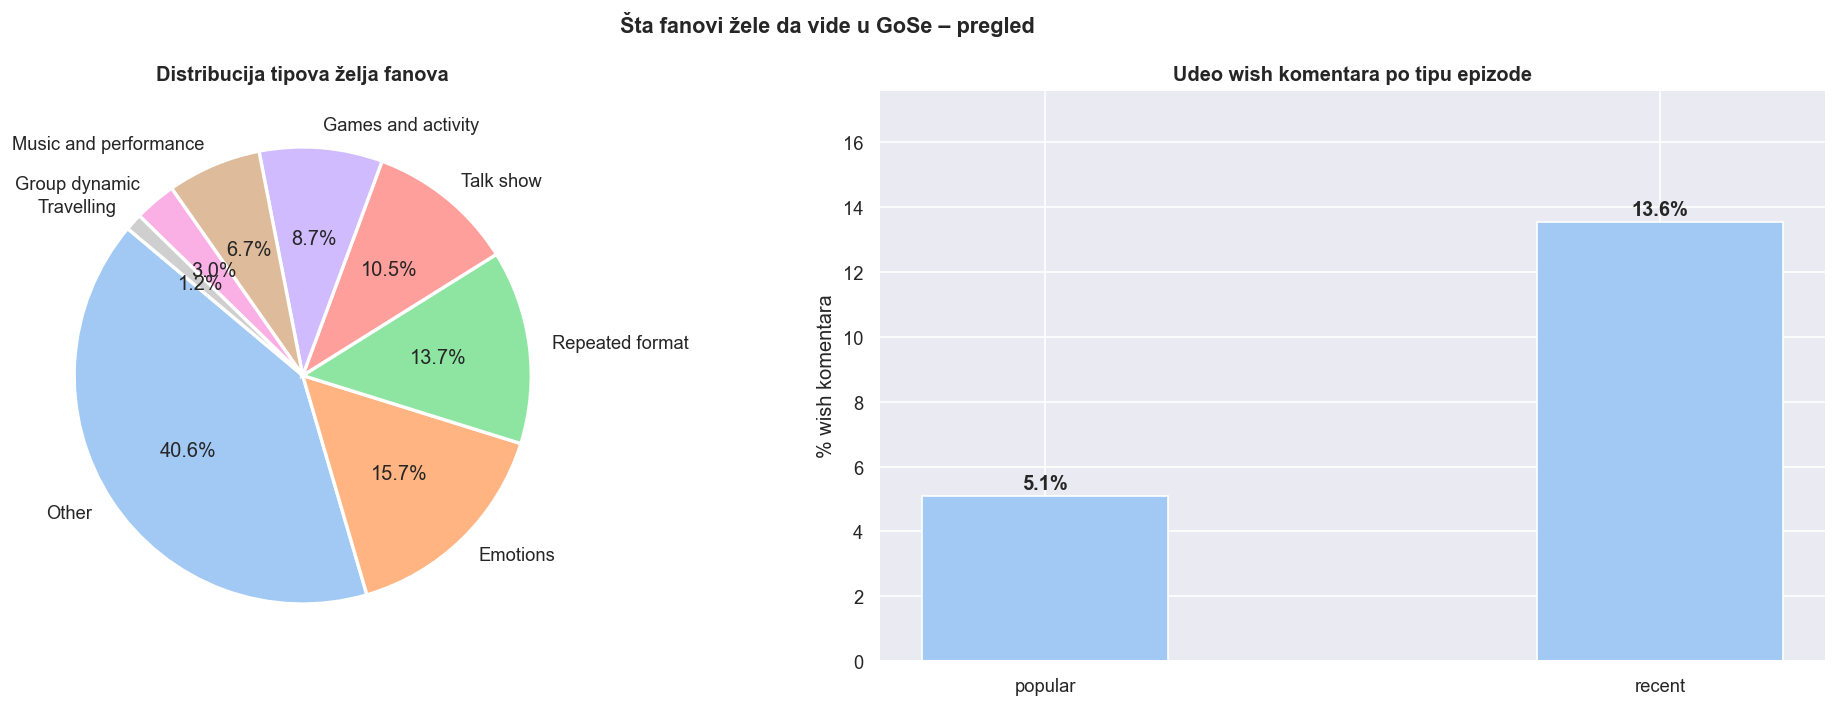


=== LIKES: Wish vs. Non-wish komentari ===
  Prosečni likes – wish:     49.87
  Prosečni likes – non-wish: 54.84
  -> Wish komentari su manje lajkovani


In [83]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

cat_counts = df_wish['wish_category'].value_counts()
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
axes[0].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            wedgeprops=wedge_props, startangle=140)
axes[0].set_title('Distribucija tipova želja fanova', fontweight='bold')

wish_by_type = df.groupby('type')['is_wish'].agg(['sum', 'count'])
wish_by_type['pct'] = wish_by_type['sum'] / wish_by_type['count'] * 100

axes[1].bar(wish_by_type.index, wish_by_type['pct'], edgecolor='white', width=0.4)
for i, (idx, row) in enumerate(wish_by_type.iterrows()):
    axes[1].text(i, row['pct'] + 0.2, f"{row['pct']:.1f}%", ha='center', fontweight='bold')
axes[1].set_title('Udeo wish komentara po tipu epizode', fontweight='bold')
axes[1].set_ylabel('% wish komentara')
axes[1].set_ylim(0, wish_by_type['pct'].max() * 1.3)

plt.suptitle('Šta fanovi žele da vide u GoSe – pregled', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== LIKES: Wish vs. Non-wish komentari ===')
print(f"  Prosečni likes – wish:     {df_wish['likes'].mean():.2f}")
print(f"  Prosečni likes – non-wish: {df[~df['is_wish']]['likes'].mean():.2f}")
print(f"  -> Wish komentari su {'vise' if df_wish['likes'].mean() > df[~df['is_wish']]['likes'].mean() else 'manje'} lajkovani")

## <font color="dodgerblue"><b> Predobrada teksta </b> </font>

### <font color="steelblue"><b> Normalizacija </b> </font>

In [84]:
def normalize(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # HTML tagovi (<a href=...>, <br>, itd.)
    text = re.sub(r'&[a-z#0-9]+;', ' ', text)     # HTML entiteti (&amp; &quot; &#39;)
    text = re.sub(r'http\S+|www\.\S+', '', text)  # URL-ovi
    text = re.sub(r'@\w+', '', text)               # @mentions
    text = re.sub(r'[^a-z\s]', '', text)           # interpunkcija i brojevi
    text = re.sub(r'\s+', ' ', text).strip()
    return text

### <font color="steelblue"><b> Tokenizacija </b> </font>

In [85]:
def tokenize(text):
    return word_tokenize(normalize(text))

### <font color="steelblue"><b> Uklanjanje stop reči </b> </font>

In [86]:
STOP_WISH = set(stopwords.words('english')) | {
    'im', 'ive', 'dont', 'cant', 'wont', 'didnt', 'isnt', 'wasnt',
    'youre', 'theyre', 'theyve', 'wouldnt', 'shouldnt', 'couldnt',
    'na', 'gonna', 'gotta', 'kinda', 'wanna',
    'yeah', 'yea', 'nah', 'ok', 'okay', 'ngl',
    'like', 'think', 'really', 'also', 'see', 'know', 'come',
    'show', 'feel', 'miss', 'episode', 'season', 'content', 'video',
    'watch', 'watching', 'next', 'back', 'more', 'go', 'one', 'time',
    'still', 'even', 'ever', 'always', 'already', 'never', 'much', 'many',
    'want', 'wish', 'hope', 'need', 'please', 'bring', 'make', 'would',
    'could', 'should', 'will', 'maybe', 'love', 'definitely',
    'gose', 'seventeen', 'svt', 'going', 'member',
    'href', 'bra', 'amp', 'quot', 'br', 'lt', 'gt', 'http', 'https', 'www',
}

def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOP_WISH and len(t) > 2]

### <font color="steelblue"><b> Lematizacija </b> </font>

In [87]:
lemm = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemm.lemmatize(t) for t in tokens]

In [88]:
df_wish['text_norm'] = df_wish['text'].apply(normalize)

df_wish['tokens'] = df_wish['text_norm'].apply(tokenize)

df_wish['tokens_nostop'] = df_wish['tokens'].apply(remove_stopwords)

df_wish['tokens_lemma'] = df_wish['tokens_nostop'].apply(lemmatize_tokens)

df_wish['text_clean'] = df_wish['tokens_lemma'].apply(lambda x: ' '.join(x))

In [89]:
all_words = [w for tokens in df_wish['tokens_lemma'] for w in tokens]

word_counts = Counter(all_words)

top_30 = word_counts.most_common(30)

print('Top 30 najčešćih reči (lemma):\n')
for word, count in top_30:
    bar = '█' * (count // max(1, top_30[0][1] // 30))
    print(f'{word:<20} {count:>5}  {bar}')

Top 30 najčešćih reči (lemma):

fun                    579  ██████████████████████████████
member                 537  ████████████████████████████
carat                  533  ████████████████████████████
get                    349  ██████████████████
game                   344  ██████████████████
jun                    333  █████████████████
hoshi                  322  ████████████████
episode                288  ███████████████
wonwoo                 287  ███████████████
jeonghan               280  ██████████████
wait                   278  ██████████████
year                   268  ██████████████
hard                   262  █████████████
team                   252  █████████████
good                   251  █████████████
happy                  251  █████████████
thank                  247  █████████████
funny                  242  ████████████
guy                    236  ████████████
excited                235  ████████████
give                   233  ████████████
thing              

## <font color="dodgerblue"><b> BERTopic – Varijanta A: Sentence Transformers + c-TF-IDF </b> </font>

In [90]:
def print_topics(model, vectorizer, n_top_words=10):
    feature_names = vectorizer.get_feature_names_out()
    
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f'Tema {idx+1}:', ', '.join(top_words))

In [91]:
mask = df_wish['text_norm'].apply(lambda x: len(x.split()) >= 3)

df_wish_filtered = df_wish[mask].reset_index(drop=True)
wish_docs_clean = df_wish_filtered['text_norm'].tolist()

print(f'Wish komentara za modeliranje: {len(wish_docs_clean):,}')

print('Ucitavam Sentence Transformers model...')
sent_model = SentenceTransformer('all-MiniLM-L6-v2')

print('Generisujem embeddings za wish komentare...')
wish_embeddings = sent_model.encode(
    wish_docs_clean,
    show_progress_bar=True,
    batch_size=32
)

print(f'Embeddings shape: {wish_embeddings.shape}')

Wish komentara za modeliranje: 4,637
Ucitavam Sentence Transformers model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generisujem embeddings za wish komentare...


Batches:   0%|          | 0/145 [00:00<?, ?it/s]

Embeddings shape: (4637, 384)


In [92]:
umap_w = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_w = HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

WISH_STOP_VEC = list(set(stopwords.words('english')) | {
    'seventeen', 'svt', 'gose', 'going', 'member',
    'want', 'wish', 'hope', 'need', 'please',
    'episode', 'video', 'content'
})

vect_w = CountVectorizer(
    stop_words=WISH_STOP_VEC,
    ngram_range=(1, 2),
    max_features=4000,
    min_df=2
)

wish_topic_model = BERTopic(
    umap_model=umap_w,
    hdbscan_model=hdbscan_w,
    vectorizer_model=vect_w,
    top_n_words=10,
    verbose=False
)

In [93]:
wish_topics, _ = wish_topic_model.fit_transform(wish_docs_clean, wish_embeddings)

wish_info = wish_topic_model.get_topic_info()

n_topics = (wish_info['Topic'] != -1).sum()
n_noise = (np.array(wish_topics) == -1).sum()

print(f'Pronadjeno semantickih tema: {n_topics}')
print(f'Komentara van tema (sum):    {n_noise} ({n_noise/len(wish_topics)*100:.1f}%)')


print('=' * 70)
print('  TEME ZELJA FANOVA – Sta fanovi konkretno zele da vide u GoSe')
print('=' * 70)

for _, row in wish_info[wish_info['Topic'] != -1].sort_values('Count', ascending=False).iterrows():
    tid = int(row['Topic'])
    words = wish_topic_model.get_topic(tid)

    if not words:
        continue

    kw = ', '.join([w for w, _ in words[:10]])
    cnt = int(row['Count'])

    print(f'\n┌── Tema {tid:2d}  ({cnt} komentara) ─────────────────────────────')
    print(f'│ Kljucne reci: {kw}')

    idxs = [i for i, t in enumerate(wish_topics) if t == tid][:4]

    print('│ Primeri komentara fanova:')
    for idx in idxs:
        ex = str(df_wish_filtered['text'].iloc[idx])
        ex = re.sub(r'<[^>]+>|&[a-z#0-9]+;', ' ', ex)
        ex = re.sub(r'\s+', ' ', ex).strip()
        print(f'│   💬 {ex[:140]}')

    print('└' + '─' * 60)

print()
print(f'Napomena: Tema -1 je "sum" – {n_noise} komentara koji ne spadaju ni u jednu jasnu kategoriju.')

Pronadjeno semantickih tema: 119
Komentara van tema (sum):    1081 (23.3%)
  TEME ZELJA FANOVA – Sta fanovi konkretno zele da vide u GoSe

┌── Tema  0  (196 komentara) ─────────────────────────────
│ Kljucne reci: miss, rewatching, episodes, team, next, miss much, excited, watching, year, behind scenes
│ Primeri komentara fanova:
│   💬 I think the production team could also create like voting or contest for the fans to give idea for Gose. It will help you with the brainstor
│   💬 my mental health not ready to watch new episode bcoz i need watching this only on my bad day. bcoz they re my happiness. ❤❤
│   💬 I have a suggestion if that s okay, GoSe should do maybe a parody of sorts of single s inferno just them being themselves tho, that would ge
│   💬 Some tips for the staff - the GOSE episodes I would love and think the boys would love too is more TTT, maybe a colour analysis series, the 
└────────────────────────────────────────────────────────────

┌── Tema  1  (120 komentara) ─────

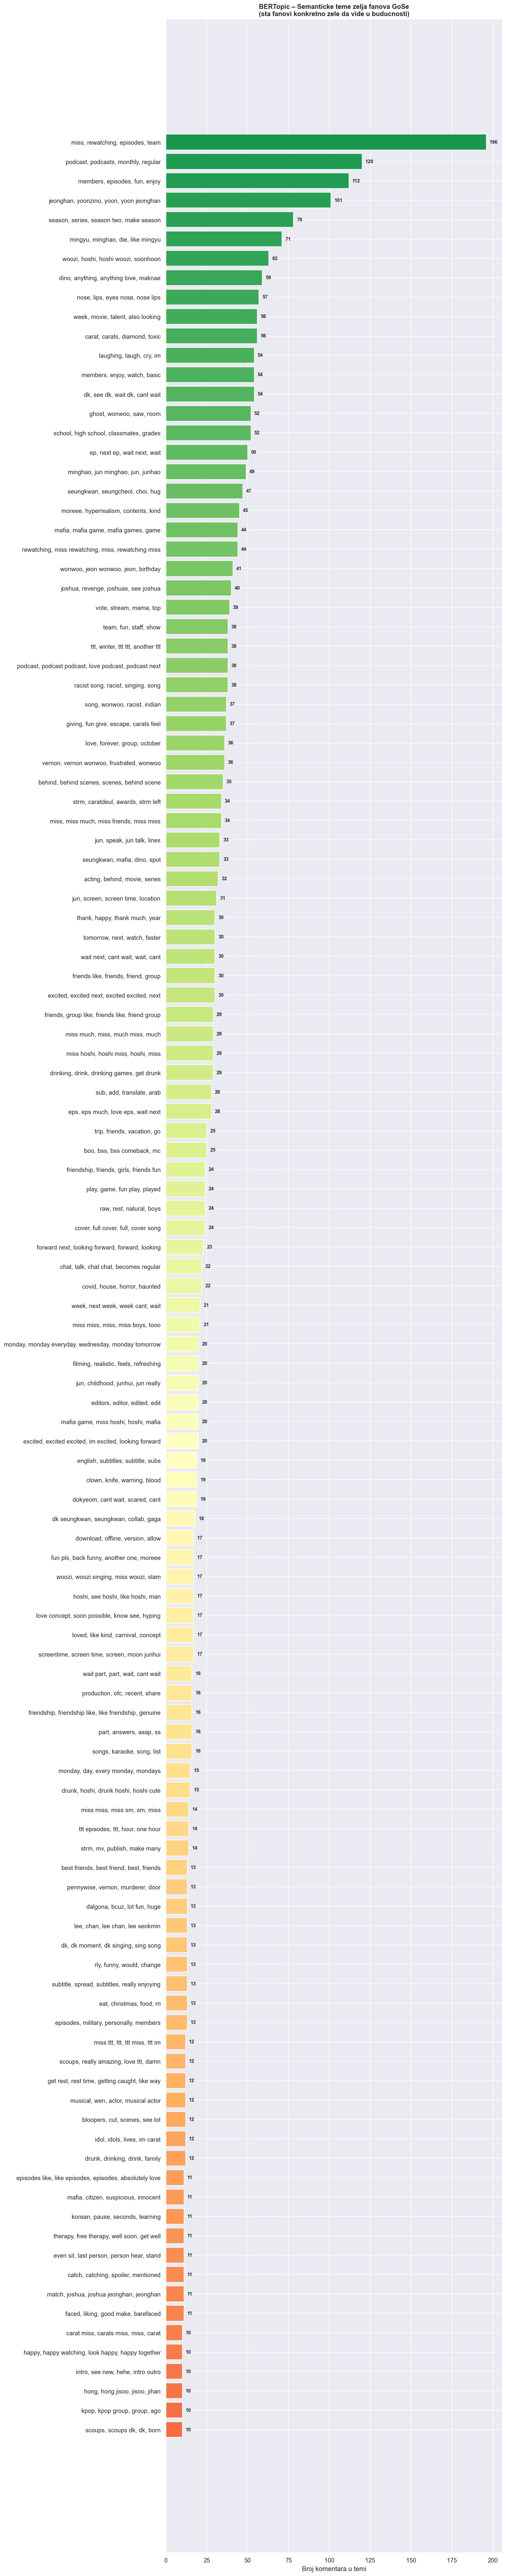

In [94]:
wish_info_valid = wish_info[wish_info['Topic'] != -1].copy()

def tema_label(tid):
    words = wish_topic_model.get_topic(tid)
    return ', '.join([w for w, _ in words[:4]]) if words else f'Tema {tid}'

wish_info_valid['label'] = wish_info_valid['Topic'].apply(tema_label)
wish_info_valid = wish_info_valid.sort_values('Count', ascending=True)

fig, ax = plt.subplots(figsize=(13, max(6, len(wish_info_valid) * 0.55)))

colors_w = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(wish_info_valid)))

bars = ax.barh(
    wish_info_valid['label'],
    wish_info_valid['Count'],
    color=colors_w,
    edgecolor='white'
)

for bar, count in zip(bars, wish_info_valid['Count']):
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'BERTopic – Semanticke teme zelja fanova GoSe\n'
    '(sta fanovi konkretno zele da vide u buducnosti)',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel('Broj komentara u temi')

plt.tight_layout()
plt.show()

## <font color="dodgerblue"><b> BERTopic – Varijanta B: Word2Vec doc embeddings </b> </font>

In [95]:
wish_topic_model2 = BERTopic(
    umap_model=umap_w,
    hdbscan_model=hdbscan_w,
    vectorizer_model=vect_w,
    top_n_words=10,
    verbose=False
)

tokenized_docs = df_wish_filtered['tokens'].tolist()

w2v_model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

def doc_embedding(tokens):
    vectors = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(w2v_model.vector_size)
    return np.mean(vectors, axis=0)

wish_embeddings = np.array([
    doc_embedding(tokens) for tokens in tokenized_docs
])

In [96]:
wish_topics2, _ = wish_topic_model2.fit_transform(wish_docs_clean, wish_embeddings)

In [97]:
wish_info2 = wish_topic_model2.get_topic_info()

n_topics2 = (wish_info2['Topic'] != -1).sum()
n_noise2 = (np.array(wish_topics2) == -1).sum()

print(f'Pronadjeno semantickih tema: {n_topics2}')
print(f'Komentara van tema (sum):    {n_noise2} ({n_noise2/len(wish_topics2)*100:.1f}%)')


print('=' * 70)
print('  TEME ZELJA FANOVA – Sta fanovi konkretno zele da vide u GoSe')
print('=' * 70)

for _, row in wish_info2[wish_info2['Topic'] != -1].sort_values('Count', ascending=False).iterrows():
    tid = int(row['Topic'])
    words = wish_topic_model2.get_topic(tid)

    if not words:
        continue

    kw = ', '.join([w for w, _ in words[:10]])
    cnt = int(row['Count'])

    print(f'\n┌── Tema {tid:2d}  ({cnt} komentara) ─────────────────────────────')
    print(f'│ Kljucne reci: {kw}')

    idxs = [i for i, t in enumerate(wish_topics2) if t == tid][:4]

    print('│ Primeri komentara fanova:')
    for idx in idxs:
        ex = str(df_wish_filtered['text'].iloc[idx])
        ex = re.sub(r'<[^>]+>|&[a-z#0-9]+;', ' ', ex)
        ex = re.sub(r'\s+', ' ', ex).strip()
        print(f'│   💬 {ex[:140]}')

    print('└' + '─' * 60)

print()
print(f'Napomena: Tema -1 je "sum" – {n_noise} komentara koji ne spadaju ni u jednu jasnu kategoriju.')

Pronadjeno semantickih tema: 135
Komentara van tema (sum):    1244 (26.8%)
  TEME ZELJA FANOVA – Sta fanovi konkretno zele da vide u GoSe

┌── Tema  0  (126 komentara) ─────────────────────────────
│ Kljucne reci: hoshi, know, jeonghan, seungkwan, die, iam, drama, seungcheol, hug, haunted house
│ Primeri komentara fanova:
│   💬 I want to see more shows that have to use more physical than brain like Dino said.
│   💬 13:21 please....i want that content #minatbanget
│   💬 i want to see dino act as a villain in drama after seeing this😆
│   💬 Now i want that board game, naiseu ❤ like it hoho
└────────────────────────────────────────────────────────────

┌── Tema  1  (91 komentara) ─────────────────────────────
│ Kljucne reci: mafia, mingyu, citizen, lol, joshua, woozi, one, wonwoo, seungkwan, dino
│ Primeri komentara fanova:
│   💬 Is minghao ok? He looked a bit tired, i hope he s doing ok 😟
│   💬 [GOSE Proposal: Jun The8 s Nostalgic Shop ] 🏮✨ How about a Healing concept where Jun and The8 s

## <font color="dodgerblue"><b> LDA - Baseline </b> </font>

K=6, log-likelihood=-299465.34
K=8, log-likelihood=-299581.24
K=10, log-likelihood=-300714.88
K=12, log-likelihood=-300961.61

Najbolji K za LDA: 6


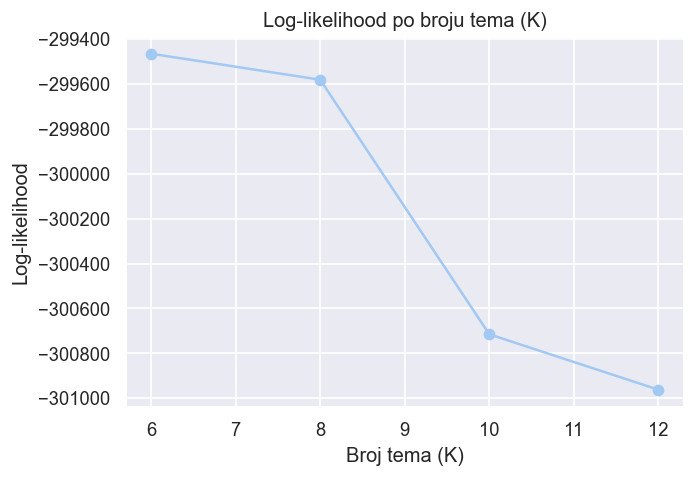

  LDA TEME ZELJA FANOVA

┌── LDA Tema 0 ─────────────────────────────────────
│ Kljucne reci: ttt, scene, behind, fun, game, concept, member, good, idea, funny, team, episode
│ Primeri:
│   💬 It would be nice to see members do more cooking (like have a competition with a special judge) , travelling content…. And it would be funny 
│   💬 Im rewatching this TTT and realized how lucky and blessed their staffs and producer must have been to be a part of this novelty content for 
│   💬 Dokyeom the gaming episode with the staff was awesome. You could build it up but I would love to see more gaming contents from the members, 
└───────────────────────────────────────────────────────

┌── LDA Tema 1 ─────────────────────────────────────
│ Kljucne reci: carat, strm, right, left, hard, caratdeul, sebongs, let, award, voting, give, smile
│ Primeri:
│   💬 ATTENTION : STR17M LEFT AND RIGHT. We are aiming DaesangS but can t even str17m their MV s. Come on Caratdeul!! Sebongs DESERVE MORE. They A
│   

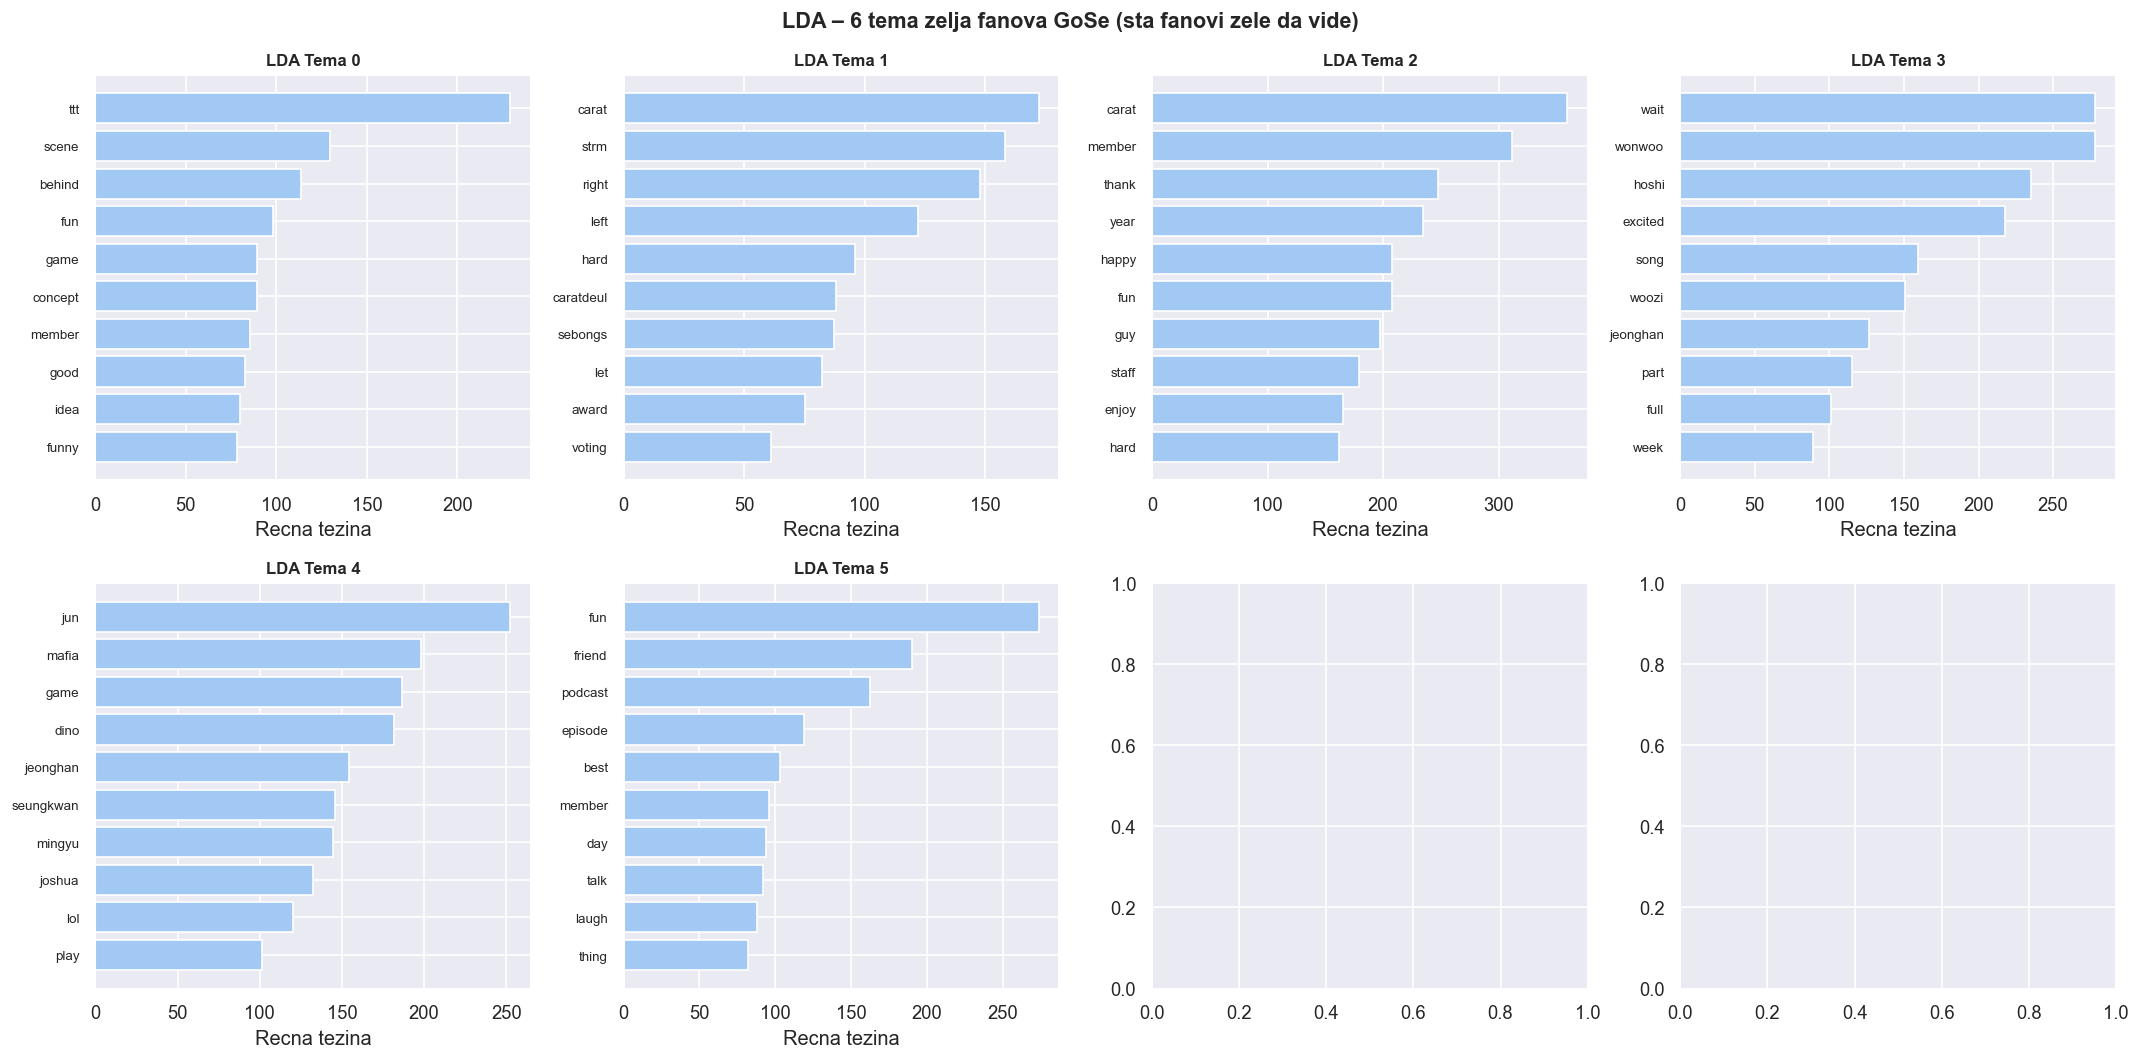

In [98]:
docs_lda = df_wish['text_clean']

vectorizer_lda = CountVectorizer(
    ngram_range=(1, 1),
    max_features=1500,
    min_df=3,
    max_df=0.9
)

X_lda = vectorizer_lda.fit_transform(docs_lda)

k_values = [6, 8, 10, 12]
lda_scores = []

for k in k_values:
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        max_iter=50,
        learning_method='batch'
    )
    lda.fit(X_lda)
    
    score = lda.score(X_lda)  # log-likelihood (veće je bolje)
    lda_scores.append(score)
    
    print(f"K={k}, log-likelihood={score:.2f}")

best_k_lda = k_values[lda_scores.index(max(lda_scores))]
print(f"\nNajbolji K za LDA: {best_k_lda}")

plt.figure(figsize=(6,4))
plt.plot(k_values, lda_scores, marker='o')
plt.title("Log-likelihood po broju tema (K)")
plt.xlabel("Broj tema (K)")
plt.ylabel("Log-likelihood")
plt.grid(True)
plt.show()

lda_model = LatentDirichletAllocation(
    n_components=best_k_lda,
    random_state=42,
    max_iter=150
)
lda_model.fit(X_lda)

feature_names_lda = vectorizer_lda.get_feature_names_out()
N_TOPICS_LDA = best_k_lda

print('=' * 70)
print('  LDA TEME ZELJA FANOVA')
print('=' * 70)

lda_topics = lda_model.transform(X_lda)

for tid in range(N_TOPICS_LDA):
    top_idx = lda_model.components_[tid].argsort()[-12:][::-1]
    kw = ', '.join([feature_names_lda[i] for i in top_idx])

    top_doc_idxs = lda_topics[:, tid].argsort()[-3:][::-1]

    print(f'\n┌── LDA Tema {tid} ─────────────────────────────────────')
    print(f'│ Kljucne reci: {kw}')
    print('│ Primeri:')

    for di in top_doc_idxs:
        ex = str(df_wish['text'].iloc[di])
        ex = re.sub(r'<[^>]+>|&[a-z#0-9]+;', ' ', ex)
        ex = re.sub(r'\s+', ' ', ex).strip()
        print(f'│   💬 {ex[:140]}')

    print('└' + '─' * 55)

fig, axes = plt.subplots((N_TOPICS_LDA+3)//4, 4, figsize=(18, 9))
axes = axes.flatten()

for tid in range(N_TOPICS_LDA):
    top_idx = lda_model.components_[tid].argsort()[-15:][::-1]
    top_words = [feature_names_lda[i] for i in top_idx]
    top_scores = [lda_model.components_[tid][i] for i in top_idx]

    axes[tid].barh(
        list(reversed(top_words[:10])),
        list(reversed(top_scores[:10])),
        edgecolor='white'
    )

    axes[tid].set_title(f'LDA Tema {tid}', fontweight='bold', fontsize=10)
    axes[tid].set_xlabel('Recna tezina')
    axes[tid].tick_params(axis='y', labelsize=8)

plt.suptitle(
    f'LDA – {best_k_lda} tema zelja fanova GoSe (sta fanovi zele da vide)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## <font color="dodgerblue"><b> NMF - Baseline </b> </font>

K=6, reconstruction error=65.15
K=8, reconstruction error=64.68
K=10, reconstruction error=64.22
K=12, reconstruction error=63.78

Najbolji K za NMF: 12


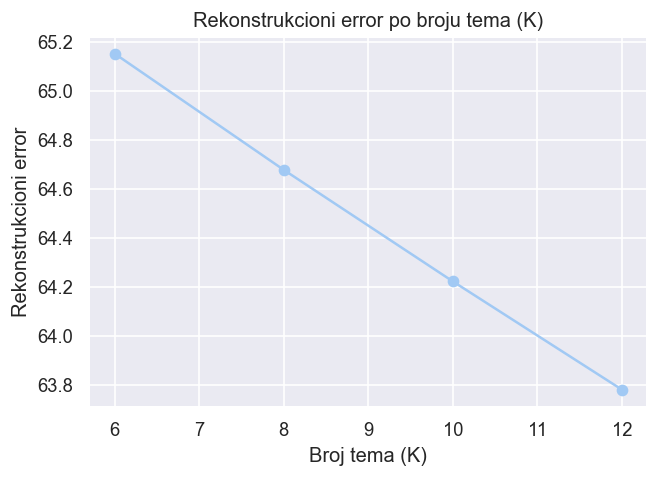

  NMF TEME ZELJA FANOVA

┌── NMF Tema 0 ─────────────────────────────────────
│ Kljucne reci: fun, member, jun, carat, game, episode, funny, happy, guy, team, thank, staff
│ Primeri:
│   💬 My thoughts. it isn t so much that thinking content isn t fun. it s just a balance of the members enthusiasm and the difficulty of the conte
│   💬 Thank you for showing us this- we know how much the members and the production staff REALLY care about the content and we appreciate this vi
│   💬 The thing i always loved about going seventeen was that how the members were always relaxed and having fun joking together eating together i
└───────────────────────────────────────────────────────

┌── NMF Tema 1 ─────────────────────────────────────
│ Kljucne reci: wait, week, wait week, part, wait part, monday, eps, omg, reaction, wait eps, wait reaction, turn
│ Primeri:
│   💬 what a cliffhanger!! I cant wait for the next episode!!
│   💬 cant wait for the next season : D
│   💬 I CANT WAIT FOR THE NEXT EP
└───

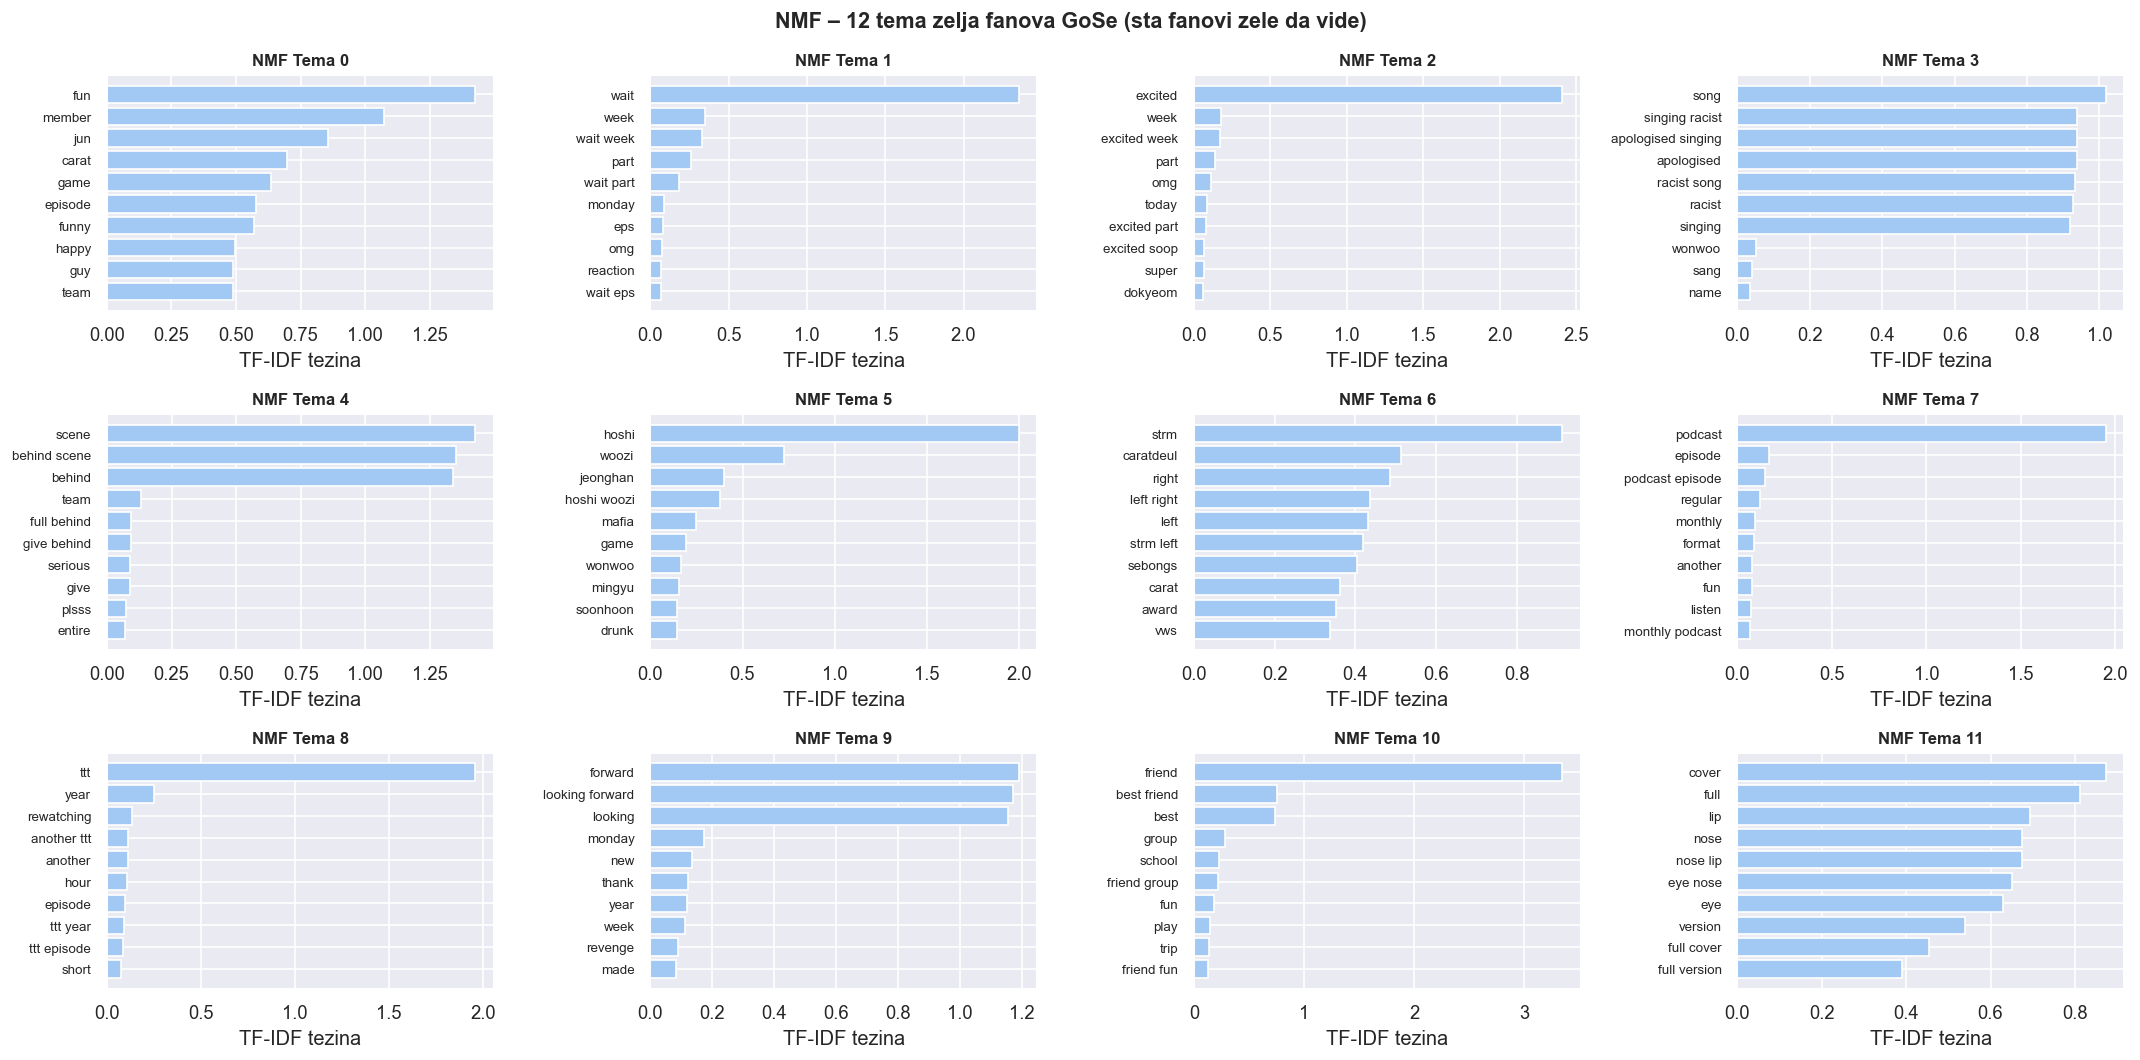

In [99]:
docs_nmf = df_wish['text_clean']

vectorizer_nmf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=3000,
    min_df=2,
    max_df=0.95
)

X_nmf = vectorizer_nmf.fit_transform(docs_nmf)

k_values = [6, 8, 10, 12]
nmf_scores = []

for k in k_values:
    nmf = NMF(n_components=k, random_state=42, max_iter=500)
    nmf.fit(X_nmf)
    
    error = nmf.reconstruction_err_
    nmf_scores.append(error)
    
    print(f"K={k}, reconstruction error={error:.2f}")

best_k_nmf = k_values[nmf_scores.index(min(nmf_scores))]
print(f"\nNajbolji K za NMF: {best_k_nmf}")

plt.figure(figsize=(6,4))
plt.plot(k_values, nmf_scores, marker='o')
plt.title("Rekonstrukcioni error po broju tema (K)")
plt.xlabel("Broj tema (K)")
plt.ylabel("Rekonstrukcioni error")
plt.grid(True)
plt.show()

nmf_model = NMF(
    n_components=best_k_nmf,
    random_state=42,
    max_iter=500
)
nmf_model.fit(X_nmf)

feature_names = vectorizer_nmf.get_feature_names_out()
N_TOPICS_NMF = best_k_nmf

print('=' * 70)
print('  NMF TEME ZELJA FANOVA')
print('=' * 70)

nmf_topics = nmf_model.transform(X_nmf)

for tid in range(N_TOPICS_NMF):
    top_idx = nmf_model.components_[tid].argsort()[-12:][::-1]
    kw = ', '.join([feature_names[i] for i in top_idx])

    top_doc_idxs = nmf_topics[:, tid].argsort()[-3:][::-1]

    print(f'\n┌── NMF Tema {tid} ─────────────────────────────────────')
    print(f'│ Kljucne reci: {kw}')
    print('│ Primeri:')

    for di in top_doc_idxs:
        ex = str(df_wish['text'].iloc[di])
        ex = re.sub(r'<[^>]+>|&[a-z#0-9]+;', ' ', ex)
        ex = re.sub(r'\s+', ' ', ex).strip()
        print(f'│   💬 {ex[:140]}')

    print('└' + '─' * 55)

fig, axes = plt.subplots((N_TOPICS_NMF+3)//4, 4, figsize=(18, 9))
axes = axes.flatten()

for tid in range(N_TOPICS_NMF):
    top_idx = nmf_model.components_[tid].argsort()[-15:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    top_scores = [nmf_model.components_[tid][i] for i in top_idx]

    axes[tid].barh(
        list(reversed(top_words[:10])),
        list(reversed(top_scores[:10])),
        edgecolor='white'
    )

    axes[tid].set_title(f'NMF Tema {tid}', fontweight='bold', fontsize=10)
    axes[tid].set_xlabel('TF-IDF tezina')
    axes[tid].tick_params(axis='y', labelsize=8)

plt.suptitle(
    f'NMF – {best_k_nmf} tema zelja fanova GoSe (sta fanovi zele da vide)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## <font color="dodgerblue"><b> Analiza želja po tipu sadržaja </b> </font>

### <font color="steelblue"><b> Format i aktivnosti koje fanovi traže </b> </font>

In [100]:
CONTENT_FORMATS = {
    '🎮 Mafia / Role-play igre': ['mafia', 'role play', 'roleplay', 'role-play', 'villain'],
    '👻 Horor / Strasni sadrzaj': ['horror', 'haunted', 'ghost', 'scary', 'fear', 'spooky', 'escape room'],
    '🍳 Kuvanje / Hrana': ['cook', 'cooking', 'food', 'eat', 'mukbang', 'recipe', 'kitchen'],
    '🎙️ Podcast / Talk format': ['podcast', 'talk', 'conversation', 'discussion', 'interview'],
    '🤸 Sports / Fizicke igre': ['sport', 'physical', 'run', 'race', 'outdoor', 'exercise', 'athletic'],
    '🧩 Quiz / Znanje': ['quiz', 'trivia', 'knowledge', 'answer', 'guessing', 'question'],
    '🎭 Improvizacija / Glumacke': ['improv', 'improvise', 'act', 'drama', 'theater', 'skit'],
    '🌍 Putovanje / Avantura': ['travel', 'trip', 'abroad', 'country', 'explore', 'adventure', 'road trip'],
    '🎵 Muzika / Performans': ['performance', 'dance', 'sing', 'cover', 'music', 'choreograph', 'stage'],
    '📹 Vlog / Behind the Scenes': ['vlog', 'behind', 'bts', 'daily', 'documentary', 'day in life'],
    '🏕️ Kampovanje / Priroda': ['camp', 'camping', 'nature', 'hiking', 'outdoor', 'wilderness'],
    '🃏 Klasicne igre / Board games': ['board game', 'card game', 'chess', 'uno', 'jenga', 'card'],
}

format_counts = {}
format_examples = {}
for fmt, keywords in CONTENT_FORMATS.items():
    pattern = '|'.join(re.escape(kw) for kw in keywords)
    mask = df_wish['text_norm'].str.contains(pattern, case=False, na=False)
    format_counts[fmt] = mask.sum()
    examples = df_wish[mask]['text_norm'].head(2).tolist()
    format_examples[fmt] = examples

format_df = pd.DataFrame(list(format_counts.items()), columns=['Format', 'Broj zelja'])
format_df = format_df[format_df['Broj zelja'] > 0].sort_values('Broj zelja', ascending=False)

print('=== FORMATI I AKTIVNOSTI KOJE FANOVI TRAZE ===')
print()
for _, row in format_df.iterrows():
    bar = '█' * int(row['Broj zelja'] / format_df['Broj zelja'].max() * 30)
    print(f"  {row['Format']:<35} {row['Broj zelja']:>5}  {bar}")
    exs = format_examples[row['Format']]
    for ex in exs[:1]:
        ex_clean = re.sub(r'<[^>]+>|&\w+;', ' ', str(ex))
        ex_clean = re.sub(r'\s+', ' ', ex_clean).strip()
        print(f"    > {ex_clean[:130]}")

=== FORMATI I AKTIVNOSTI KOJE FANOVI TRAZE ===

  🎭 Improvizacija / Glumacke            442  ██████████████████████████████
    > please do a reads thirst tweets episode can just use all the ones nothing funnier than dino doing improv
  🎵 Muzika / Performans                 432  █████████████████████████████
    > honestly i agree with dino i think they keep making more serious contents like using their brains too much the concept of going se
  🎙️ Podcast / Talk format              344  ███████████████████████
    > a lot of the discussion was centered around what fans like to watch and that the members need to work harder i believe the members
  🍳 Kuvanje / Hrana                     294  ███████████████████
    > i think the production team could also create like voting or contest for the fans to give idea for gose it will help you with the 
  📹 Vlog / Behind the Scenes            151  ██████████
    > as someone who started stanning seventen because of gose i just want to say that te

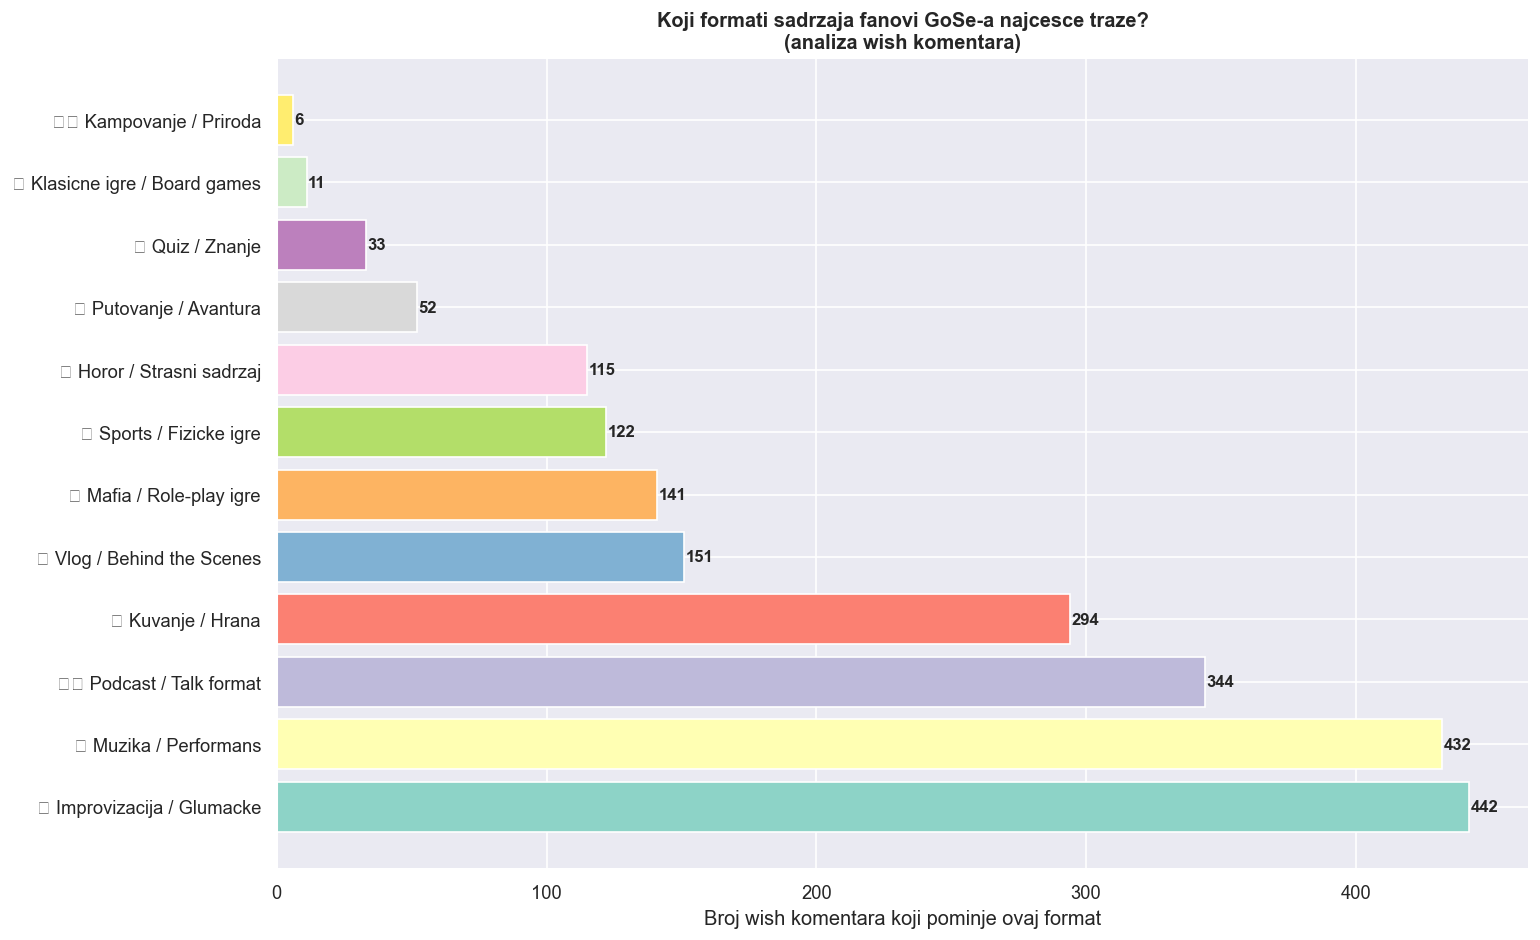

In [101]:
fig, ax = plt.subplots(figsize=(13, 8))
colors_fmt = plt.cm.Set3(np.linspace(0, 1, len(format_df)))
bars = ax.barh(format_df['Format'], format_df['Broj zelja'],
               color=colors_fmt, edgecolor='white')
for bar, count in zip(bars, format_df['Broj zelja']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            str(count), va='center', fontsize=10, fontweight='bold')
ax.set_title('Koji formati sadrzaja fanovi GoSe-a najcesce traze?\n(analiza wish komentara)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Broj wish komentara koji pominje ovaj format')
plt.tight_layout()
plt.show()

### <font color="steelblue"><b> Želje vezane za članove grupe </b> </font>

In [102]:
MEMBERS = {
    'S.Coups':   ['scoups', 's.coups', 'seungcheol', 'choi seungcheol'],
    'Jeonghan':  ['jeonghan', 'yoon jeonghan'],
    'Joshua':    ['joshua', 'josh', 'jisoo', 'hong jisoo'],
    'Jun':       ['jun', 'wen junhui', 'junhui'],
    'Hoshi':     ['hoshi', 'soonyoung', 'kwon soonyoung'],
    'Wonwoo':    ['wonwoo', 'jeon wonwoo'],
    'Woozi':     ['woozi', 'jihoon', 'lee jihoon'],
    'The8':      ['the8', 'theeight', 'minghao', 'xu minghao'],
    'Mingyu':    ['mingyu', 'kim mingyu'],
    'DK':        ['dk', 'dokyeom', 'seokmin', 'lee seokmin'],
    'Seungkwan': ['seungkwan', 'boo seungkwan', 'boo'],
    'Vernon':    ['vernon', 'hansol', 'chwe hansol'],
    'Dino':      ['dino', 'chan', 'lee chan'],
}

member_wish_counts = {}
member_wish_examples = {}
for member, aliases in MEMBERS.items():
    pattern = r'\b(' + '|'.join(re.escape(a) for a in aliases) + r')\b'
    mask = df_wish['text_norm'].str.contains(pattern, case=False, na=False)
    member_wish_counts[member] = mask.sum()
    member_wish_examples[member] = df_wish[mask]['text'].head(2).tolist()

member_wish_df = pd.DataFrame(list(member_wish_counts.items()), columns=['Clan', 'Wish pominjanja'])
member_wish_df = member_wish_df.sort_values('Wish pominjanja', ascending=False)

print('=== CLANOVI U WISH KOMENTARIMA – Ko fanovi traze u buducim epizodama ===')
print()
for _, row in member_wish_df.iterrows():
    bar = '█' * int(row['Wish pominjanja'] / member_wish_df['Wish pominjanja'].max() * 30)
    print(f"  {row['Clan']:<12} {row['Wish pominjanja']:>5}  {bar}")
    exs = member_wish_examples[row['Clan']]
    for ex in exs[:1]:
        ex_clean = re.sub(r'<[^>]+>|&\w+;', ' ', str(ex))
        ex_clean = re.sub(r'\s+', ' ', ex_clean).strip()
        print(f"    > {ex_clean[:130]}")

=== CLANOVI U WISH KOMENTARIMA – Ko fanovi traze u buducim epizodama ===

  Jun            312  ██████████████████████████████
    > Yes. Relaxing is the best, I love it when they feel enjoying. I can see the changes that it seems to be more dutiful than enjoying
  Hoshi          285  ███████████████████████████
    > To Seventeen, I hope you don’t feel pressured to make content for us. Of course, we’re really grateful that you always show us suc
  DK             278  ██████████████████████████
    > Long time carat from Singapore 싱가포르에서 온 오래된 캐럿입니다 Listing some ideas in case it helps with brainstorming! 아이디어 브레인스토밍에 도움이 될까 해서 몇
  Jeonghan       226  █████████████████████
    > Culinary war cosplay would be fun. The historical drama can be interesting as well. They can also do an escape room with missions 
  Wonwoo         217  ████████████████████
    > I think you guys are being too hard on yourselves. I particularly liked the pico park episodes, and I enjoy watching game channels
  

### <font color="steelblue"><b> Trend želja - stare vs nove epizode </b> </font>

Wish komentara na popularnim epizodama: 3,296
Wish komentara na nedavnim epizodama:   1,342

=== DISTRIBUCIJA TIPOVA ZELJA PO TIPU EPIZODE (%) ===
type                   popular  recent
wish_category                         
Other                     46.1    27.3
Emotions                  15.7    15.6
Repeated format           13.1    15.2
Music and performance      8.3     2.5
Games and activity         7.8    11.0
Talk show                  4.8    24.4
Group dynamic              2.9     3.1
Travelling                 1.3     0.9


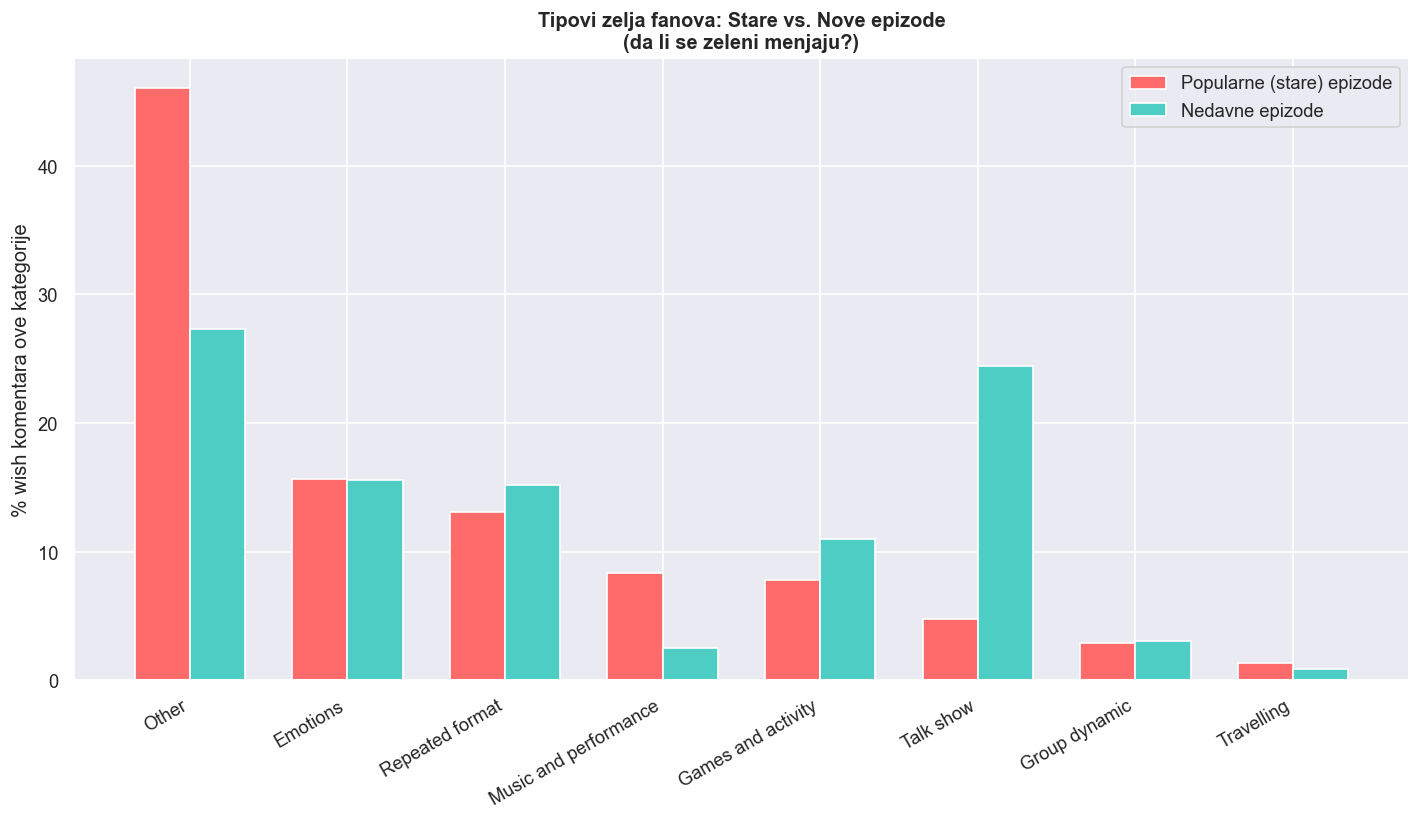


Interpretacija: Ako tip zelje dominira na starim epizodama, fanovi zele povratak tog formata.
Ako dominira na novim, fanovi aktivno traze novi sadrzaj.


In [103]:
wish_popular = df_wish[df_wish['type'] == 'popular']
wish_recent  = df_wish[df_wish['type'] == 'recent']

print(f'Wish komentara na popularnim epizodama: {len(wish_popular):,}')
print(f'Wish komentara na nedavnim epizodama:   {len(wish_recent):,}')

cat_by_type = pd.crosstab(df_wish['wish_category'], df_wish['type'], normalize='columns') * 100
cat_by_type = cat_by_type.sort_values('popular', ascending=False)

print('\n=== DISTRIBUCIJA TIPOVA ZELJA PO TIPU EPIZODE (%) ===')
print(cat_by_type.round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(cat_by_type))
w = 0.35

pop_vals = cat_by_type.get('popular', pd.Series(0, index=cat_by_type.index)).values
rec_vals = cat_by_type.get('recent',  pd.Series(0, index=cat_by_type.index)).values

bars1 = ax.bar(x - w/2, pop_vals, w, label='Popularne (stare) epizode', color='#FF6B6B', edgecolor='white')
bars2 = ax.bar(x + w/2, rec_vals, w, label='Nedavne epizode',           color='#4ECDC4', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(cat_by_type.index, rotation=30, ha='right')
ax.set_ylabel('% wish komentara ove kategorije')
ax.set_title('Tipovi zelja fanova: Stare vs. Nove epizode\n(da li se zeleni menjaju?)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nInterpretacija: Ako tip zelje dominira na starim epizodama, fanovi zele povratak tog formata.')
print('Ako dominira na novim, fanovi aktivno traze novi sadrzaj.')

## <font color="dodgerblue"><b> Rangiranje želja </b> </font>

In [104]:
print('=' * 70)
print('  FINALNO RANGIRANJE ZELJA FANOVA GoSe-a')
print('  (sta kreatori sadrzaja treba da imaju u vidu)')
print('=' * 70)

format_stats = []
for fmt, keywords in CONTENT_FORMATS.items():
    pattern = '|'.join(re.escape(kw) for kw in keywords)
    mask = df_wish['text_norm'].str.contains(pattern, case=False, na=False)
    cnt = mask.sum()
    if cnt == 0:
        continue
    avg_likes = df_wish[mask]['likes'].mean()
    pct_popular = df_wish[mask & (df_wish['type'] == 'popular')].shape[0] / max(cnt, 1) * 100
    pct_recent  = df_wish[mask & (df_wish['type'] == 'recent')].shape[0]  / max(cnt, 1) * 100
    konsistentna = min(pct_popular, pct_recent) / max(max(pct_popular, pct_recent), 1) * 100

    format_stats.append({
        'Format': fmt,
        'Broj zelja': cnt,
        'Prosecni likes': round(avg_likes, 2),
        '% na starim': round(pct_popular, 1),
        '% na novim': round(pct_recent, 1),
        'Konzistentnost (%)': round(konsistentna, 1),
    })

stats_df = pd.DataFrame(format_stats)
if len(stats_df) > 0:
    stats_df['score_cnt']   = stats_df['Broj zelja']   / stats_df['Broj zelja'].max()
    stats_df['score_likes'] = stats_df['Prosecni likes'] / stats_df['Prosecni likes'].max()
    stats_df['score_kons']  = stats_df['Konzistentnost (%)'] / 100
    stats_df['Ukupni skor'] = (
        0.5 * stats_df['score_cnt'] +
        0.3 * stats_df['score_likes'] +
        0.2 * stats_df['score_kons']
    ).round(3)
    stats_df = stats_df.sort_values('Ukupni skor', ascending=False).reset_index(drop=True)
    stats_df['Rang'] = range(1, len(stats_df) + 1)

    for _, row in stats_df.iterrows():
        medal = '🥇' if row['Rang'] == 1 else '🥈' if row['Rang'] == 2 else '🥉' if row['Rang'] == 3 else f"#{int(row['Rang'])}"
        print(f"\n  {medal} {row['Format']}")
        print(f"     Broj zelja:       {int(row['Broj zelja'])}")
        print(f"     Prosecni likes:   {row['Prosecni likes']}")
        print(f"     Konzistentnost:   {row['Konzistentnost (%)']:.0f}% (zastupljenost na oba tipa epizoda)")
        print(f"     Ukupni skor:      {row['Ukupni skor']:.3f}")

  FINALNO RANGIRANJE ZELJA FANOVA GoSe-a
  (sta kreatori sadrzaja treba da imaju u vidu)

  🥇 🎭 Improvizacija / Glumacke
     Broj zelja:       442
     Prosecni likes:   52.5
     Konzistentnost:   99% (zastupljenost na oba tipa epizoda)
     Ukupni skor:      0.833

  🥈 🎵 Muzika / Performans
     Broj zelja:       432
     Prosecni likes:   47.17
     Konzistentnost:   33% (zastupljenost na oba tipa epizoda)
     Ukupni skor:      0.675

  🥉 🍳 Kuvanje / Hrana
     Broj zelja:       294
     Prosecni likes:   29.63
     Konzistentnost:   92% (zastupljenost na oba tipa epizoda)
     Ukupni skor:      0.593

  #4 🎙️ Podcast / Talk format
     Broj zelja:       344
     Prosecni likes:   46.62
     Konzistentnost:   26% (zastupljenost na oba tipa epizoda)
     Ukupni skor:      0.559

  #5 📹 Vlog / Behind the Scenes
     Broj zelja:       151
     Prosecni likes:   117.2
     Konzistentnost:   34% (zastupljenost na oba tipa epizoda)
     Ukupni skor:      0.538

  #6 👻 Horor / Strasni sa

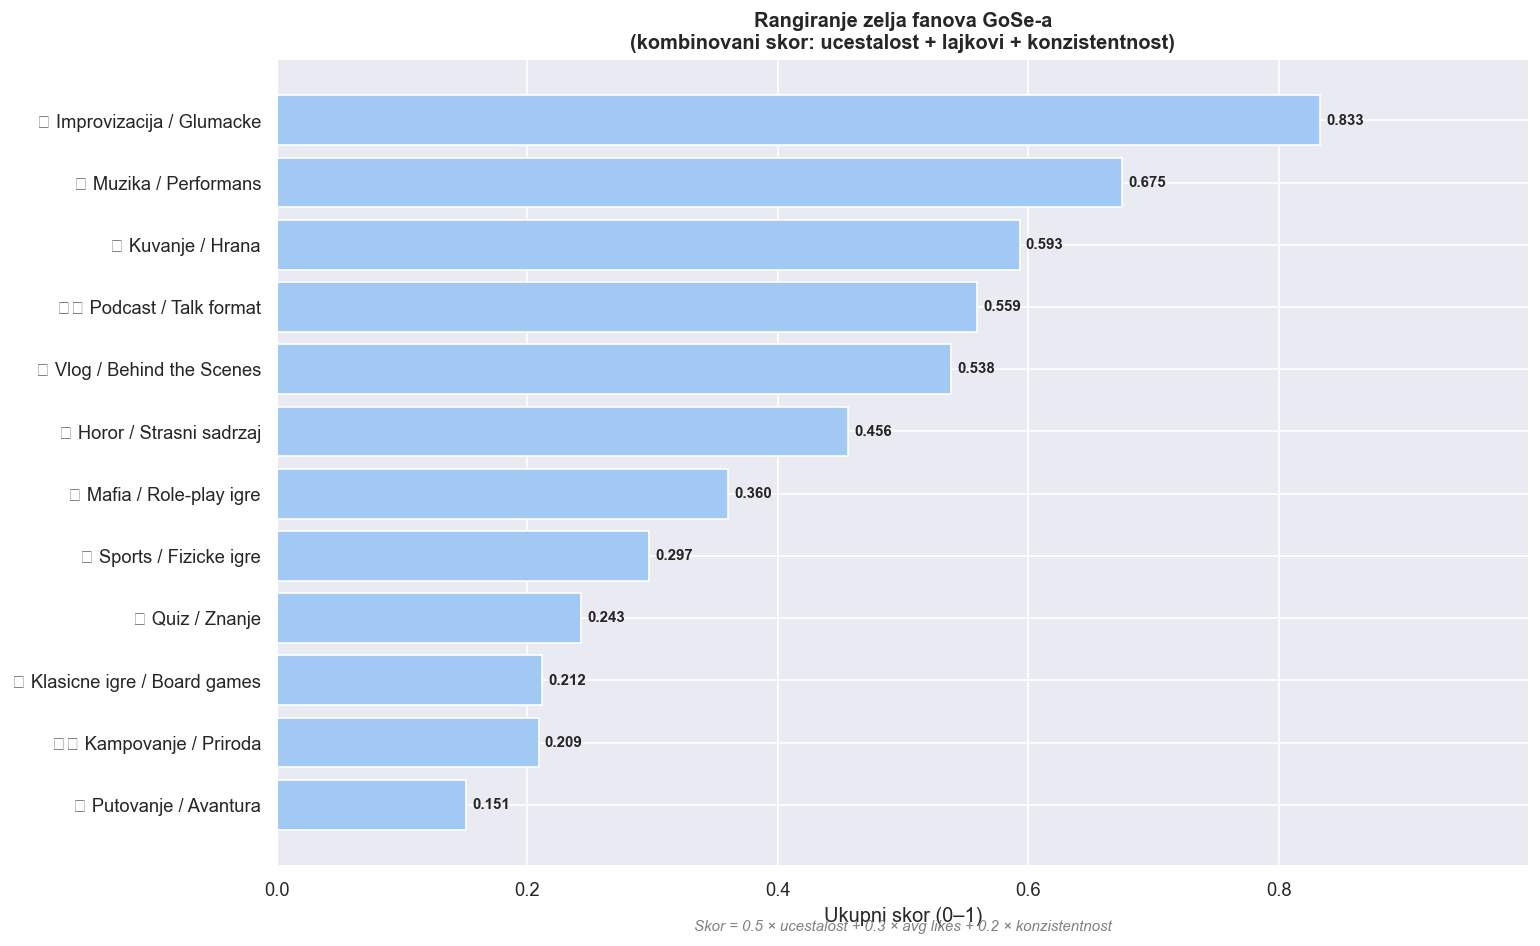

In [105]:
if len(stats_df) > 0:
    fig, ax = plt.subplots(figsize=(13, 8))
    bars = ax.barh(stats_df['Format'][::-1], stats_df['Ukupni skor'][::-1], edgecolor='white')
    for bar, score in zip(bars, stats_df['Ukupni skor'][::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{score:.3f}', va='center', fontsize=9, fontweight='bold')

    ax.set_title('Rangiranje zelja fanova GoSe-a\n(kombinovani skor: ucestalost + lajkovi + konzistentnost)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Ukupni skor (0–1)')
    ax.set_xlim(0, stats_df['Ukupni skor'].max() * 1.2)

    legend_text = 'Skor = 0.5 × ucestalost + 0.3 × avg likes + 0.2 × konzistentnost'
    ax.text(0.5, -0.08, legend_text, transform=ax.transAxes,
            ha='center', fontsize=9, style='italic', color='gray')
    plt.tight_layout()
    plt.show()

## <font color="dodgerblue"><b> Evaluacija i poredenje modela </b> </font>